# **CUSTOMER CHURN PREDICTION AND STRATEGIC DATA ANALYSIS**
This notebook is designed to perform Exploratory Data Analysis (EDA) on customer churn and implement feature engineering for Machine Learning models.

Project Workflow:
1. Setup and Initial Data Exploration
2. Impact of Categorical Variables on Churn (EDA)
3. EDA Insights and Strategic Action Plan
4. Feature Engineering (Encoding) and Correlation Analysis
5. Correlation Analysis: Golden Insights

# *1.Setup and data loading*

In [48]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
import warnings



# *--Plotting settings and ignoring warnings*




In [49]:
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)


#*--Load the dataset*

In [50]:
df = pd.read_csv('cleaned_data.csv')

#---Inıtıal data exploration-

In [51]:
print("--- First 5 Rows of the Dataset ---")
display(df.head())

print("\n--- Data Types and Structure ---")
df.info()

print("\n--- Statistical Summary of Numerical Columns ---")
display(df.describe())

print("\n--- Target Variable (Churn) Distribution ---")
print(df['Churn'].value_counts())

--- First 5 Rows of the Dataset ---


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes



--- Data Types and Structure ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentM

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000



--- Target Variable (Churn) Distribution ---
Churn
No     5174
Yes    1869
Name: count, dtype: int64


## *2. Impact of Categorical Variables on Churn (EDA)*
In this section, we automatically identify all categorical variables and visualize their relationship with customer churn using a dynamically generated grid layout.

Detected 16 categorical features for visualization.


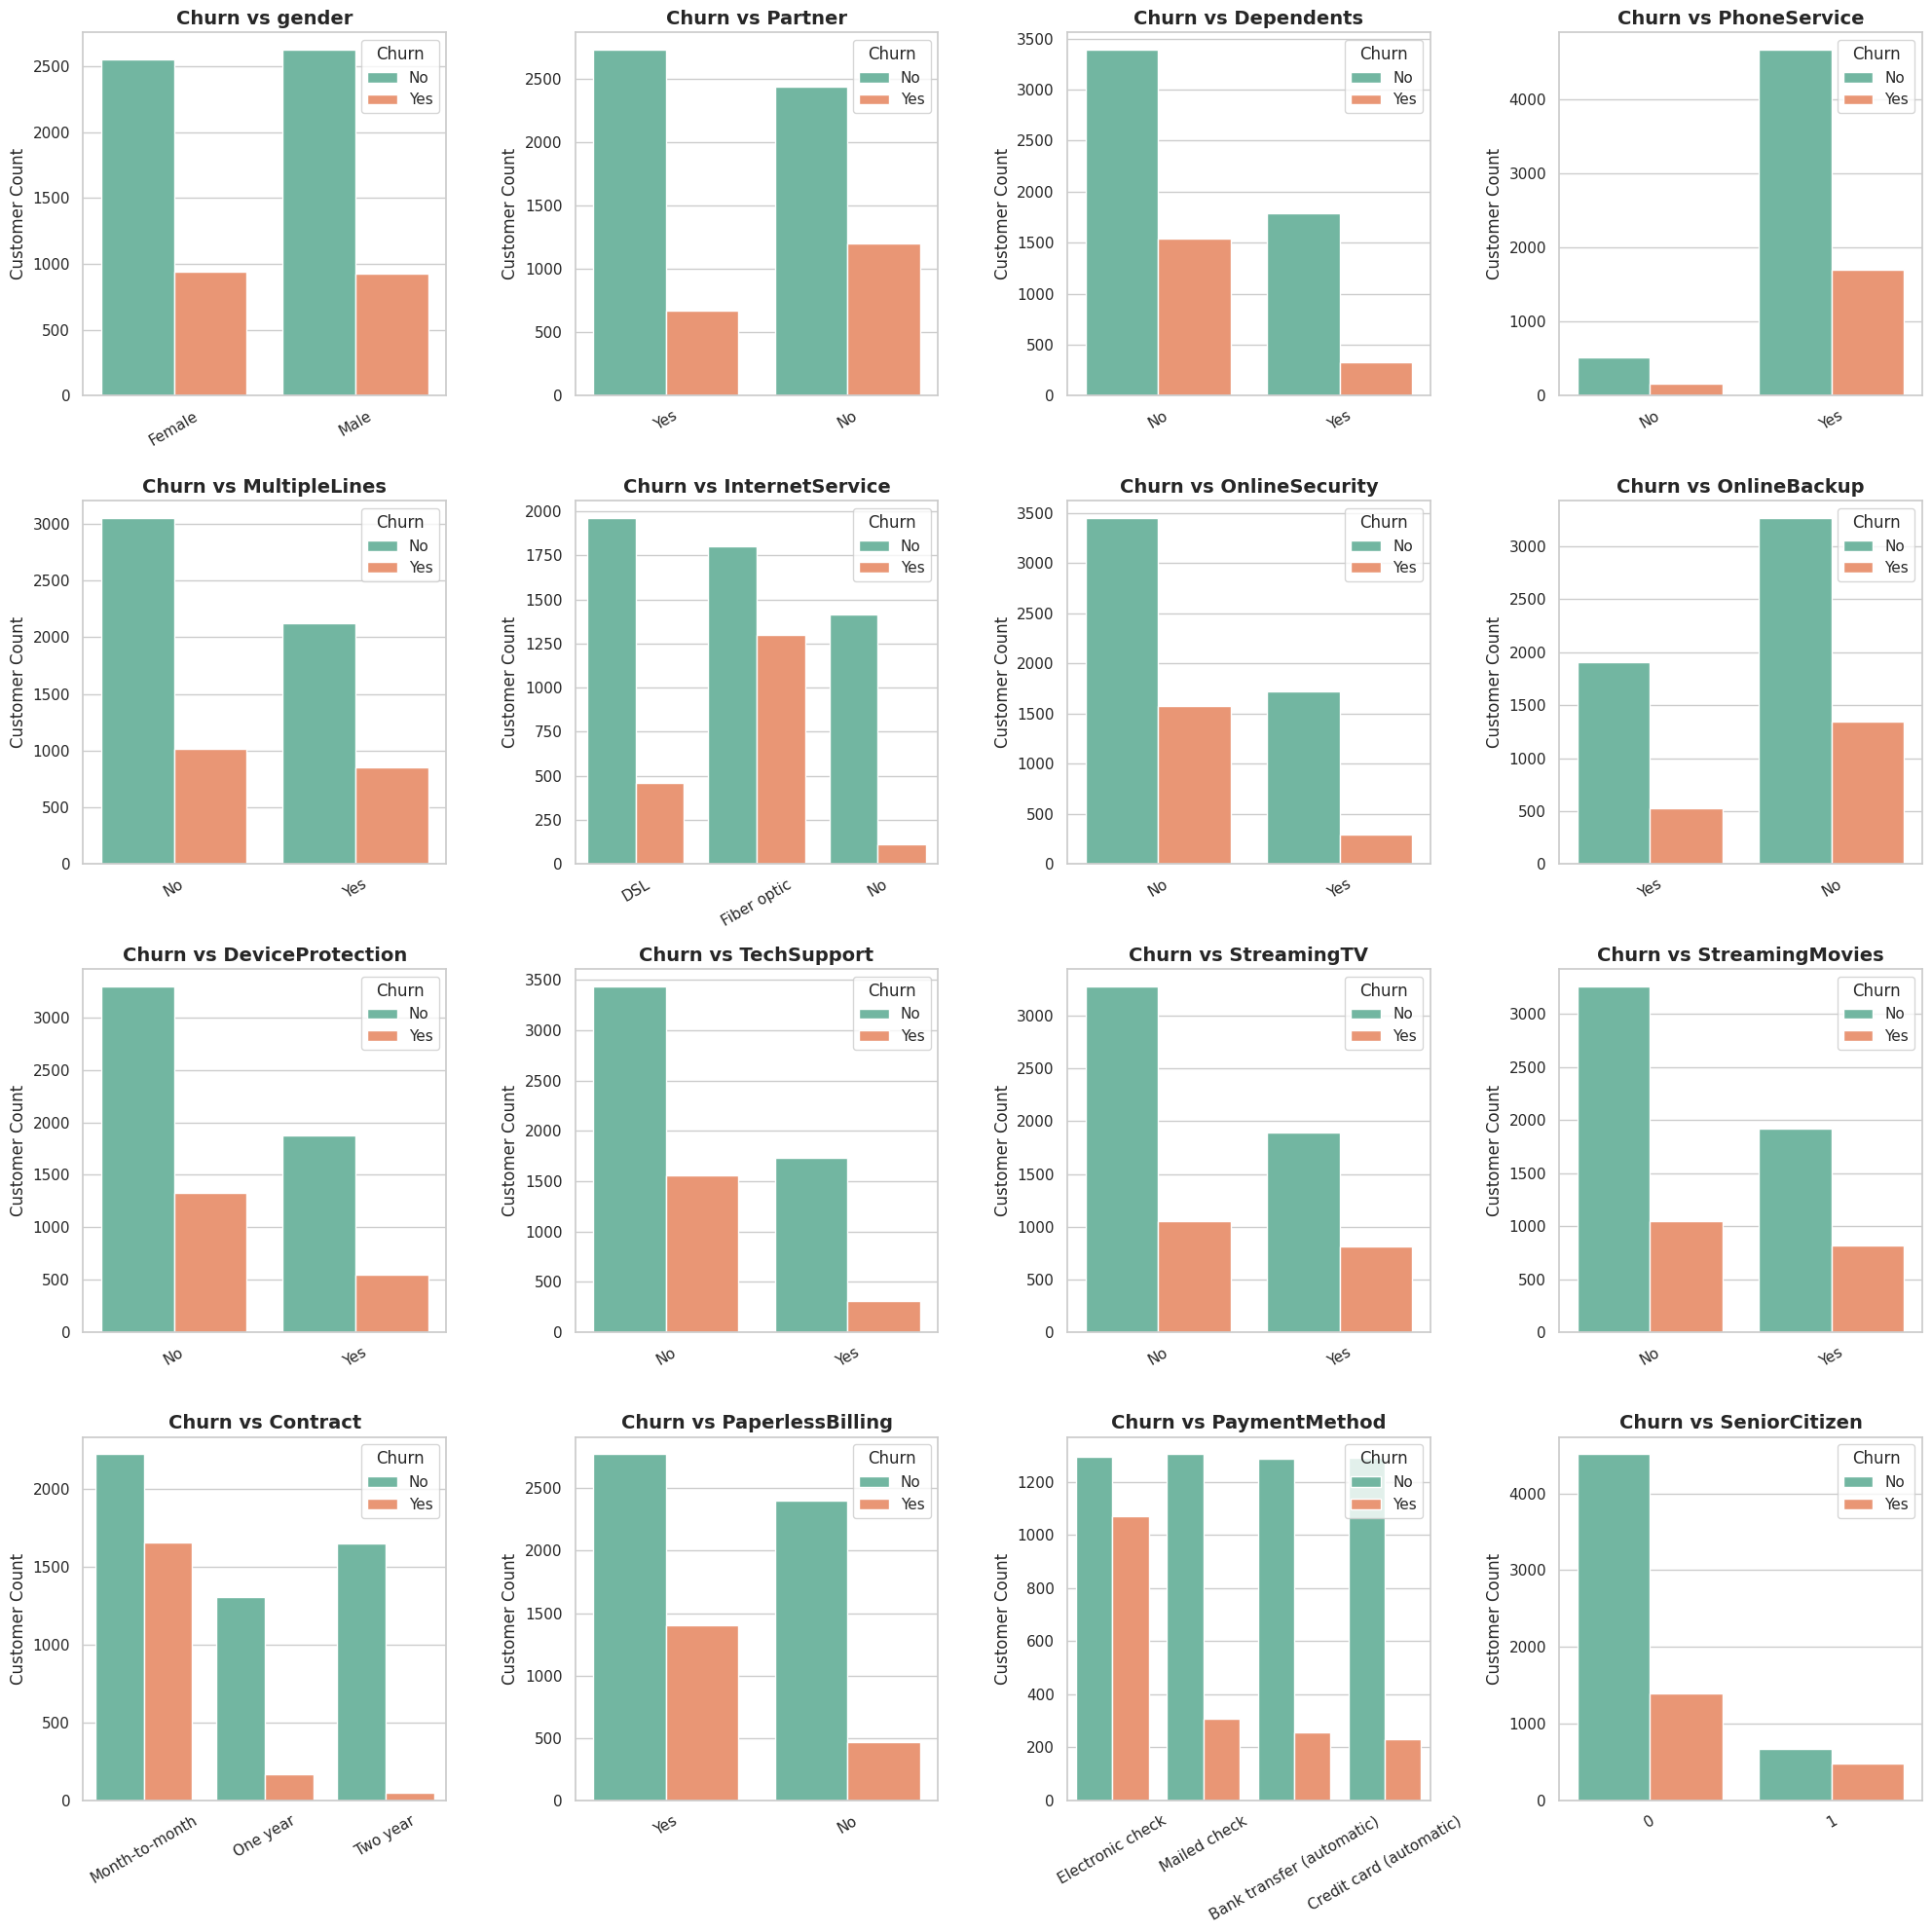

In [46]:
# --- 2. CATEGORICAL FEATURES VISUALIZATION ---

# Automatically identify categorical columns (The shorter, cleaner way)
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

# Remove 'customerID' and 'Churn' from the list if they exist
cols_to_remove = ['customerID', 'Churn']
categorical_cols = [col for col in categorical_cols if col not in cols_to_remove]

# Add 'SeniorCitizen' to the list explicitly (since it's usually int64 but represents categories)
if 'SeniorCitizen' in df.columns and 'SeniorCitizen' not in categorical_cols:
    categorical_cols.append('SeniorCitizen')

print(f"Detected {len(categorical_cols)} categorical features for visualization.")

# Dynamically calculate grid size based on the number of features
num_cols = len(categorical_cols)
ncols = 4
nrows = math.ceil(num_cols / ncols)

# Create the grid
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(20, 5 * nrows))
axes = axes.flatten()

# Loop through features and plot
for i, col in enumerate(categorical_cols):
    sns.countplot(data=df, x=col, hue='Churn', ax=axes[i], palette='Set2')
    axes[i].set_title(f'Churn vs {col}', fontsize=14, fontweight='bold')
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Customer Count')

# Hide any extra empty subplots if the number of features is not a perfect multiple of 4
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## *3. EDA Insights and Strategic Action Plan*
Veri setinden elde edilen iş içgörüleri (business insights) öncelik sırasına göre aşağıda listelenmiştir:

### 🔴 YÜKSEK ÖNCELİK (Kritik ve Acil Aksiyonlar)
* **1. Contract (Sözleşme Tipi):** **İlişki:** Çok Güçlü (Aylık sözleşmelerde kaçış tavan yapıyor). **Aksiyon:** Aylık sözleşmeli müşteriler yıllığa ikna edilirse churn üzerinde çok büyük ve net bir etkisi olur.
* **2. Internet Service (İnternet Servisi):** **İlişki:** Çok Güçlü (Fiber optik kullanıcıları hızla kaçıyor). **Aksiyon:** Fiber optik altyapısı veya fiyatlandırma politikası acilen revize edilmeli.
* **3. Payment Method (Ödeme Yöntemi):** **İlişki:** Güçlü (Elektronik çek/manuel ödeyenlerin riski yüksek). **Aksiyon:** Manuel ödeme yapan kitleyi, çeşitli kampanyalarla otomatik ödemeye ikna edebiliriz.
* **4. Tech Support (Teknik Destek):** **İlişki:** Güçlü (Teknik destek almayanlar ilk sorunda rakibe gidiyor). **Aksiyon:** Riskli görünen, yeni gelen veya yüksek faturalı müşterilere öncelikli teknik destek sağlanabilir.

### 🟡 ORTA ÖNCELİK (Sadakat ve Paket Stratejileri)
* **5. Online Security & 6. Online Backup:** **İlişki:** Belirgin. **Aksiyon:** Güvenlik ve yedekleme hizmetlerini standart paket haline getirmek müşteri kaybını doğrudan düşürür.
* **7. Device Protection:** **İlişki:** Belirgin. **Aksiyon:** Donanım garantisi güven verdiğinden bu paketlerin satışına önem verilebilir.
* **8. Dependents & 9. Partner:** **İlişki:** Orta. **Aksiyon:** Bireysel ve yalnız yaşayan kitle en büyük risk grubudur. Bu kitleyi sisteme bağlamak için "Aile ve Partner Paketleri" teşviki sağlanmalı.
* **10. Senior Citizen (Yaşlı Müşteriler):** **İlişki:** Orta. **Aksiyon:** Bu kitleye özel indirim ya da kullanım kolaylığı sağlayan destek kanalları açılabilir.

### 🟢 DÜŞÜK ÖNCELİK (Destekleyici ve Etkisiz Elemanlar)
* **11. Streaming Movies & 12. Streaming TV:** **Aksiyon:** Uzun süreli sözleşmeler (taahhütler) için bir promosyon/hediye olarak verilebilir.
* **13. Paperless Billing:** **Aksiyon:** Bu dijital kitleyi elde tutmak için "Dijital Sadakat Programı" kurgulanabilir.
* **Etkisiz Elemanlar (Gender, Phone Service, Multiple Lines):** **İlişki:** Yok/Çok Zayıf. **Aksiyon:** Modellemede ve stratejide vakit harcanmamalıdır.

# *4. Feature Engineering (Encoding) and Correlation Analysis*


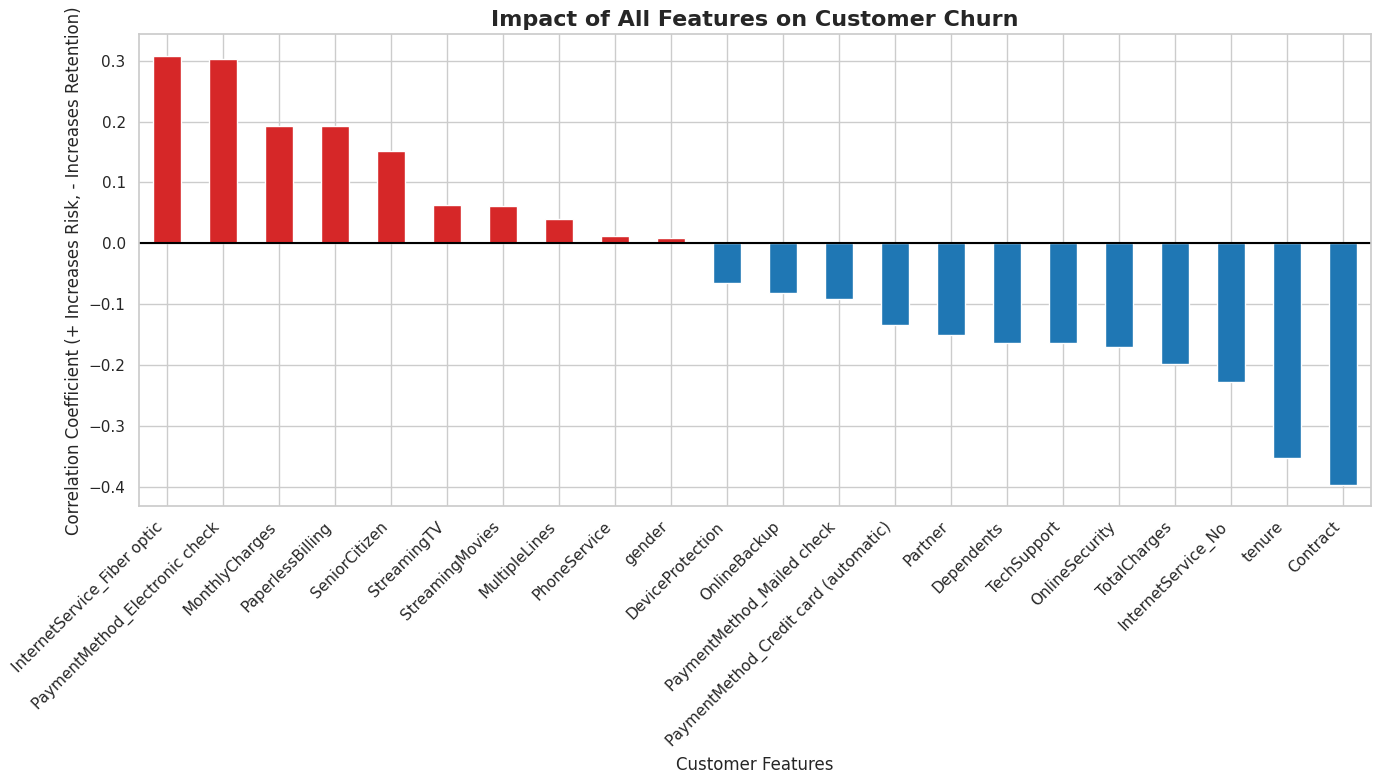

In [47]:

# Work on a copy of the dataframe to preserve the original textual data
df_encoded = df.copy()

# 1. Binary Encoding (0 and 1)
# Dynamically find binary columns (columns with exactly 2 unique values, excluding target if handled separately)
binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
               'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
               'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'Churn']

# Apply encoding safely
for col in binary_cols:
    if col in df_encoded.columns:
        if col == 'gender':
            df_encoded[col] = df_encoded[col].map({'Female': 1, 'Male': 0})
        else:
            df_encoded[col] = df_encoded[col].map({'Yes': 1, 'No': 0})

# 2. Ordinal Encoding for Contract type
if 'Contract' in df_encoded.columns:
    df_encoded['Contract'] = df_encoded['Contract'].map({'Month-to-month': 0, 'One year': 1, 'Two year': 2})

# 3. One-Hot Encoding for remaining nominal variables
cols_to_get_dummies = ['PaymentMethod', 'InternetService']
existing_dummy_cols = [c for c in cols_to_get_dummies if c in df_encoded.columns]
df_encoded = pd.get_dummies(data=df_encoded, columns=existing_dummy_cols, drop_first=True)

# --- CORRELATION BAR CHART ---
plt.figure(figsize=(14, 8))

# Calculate correlation with Churn and sort
churn_corr = df_encoded.corr()['Churn'].drop('Churn').sort_values(ascending=False)

# Color coding: Red for positive correlation (Risk), Blue for negative correlation (Retention)
colors = ['#d62728' if x > 0 else '#1f77b4' for x in churn_corr]
churn_corr.plot(kind='bar', color=colors)

# Plot formatting
plt.title('Impact of All Features on Customer Churn', fontsize=16, fontweight='bold')
plt.ylabel('Correlation Coefficient (+ Increases Risk, - Increases Retention)', fontsize=12)
plt.xlabel('Customer Features', fontsize=12)
plt.axhline(0, color='black', linewidth=1.5)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

##  *5. Correlation Analysis: Golden Insights*
Matematiksel korelasyon haritası, Makine Öğrenmesi (Machine Learning) modelimizin ağırlık vereceği temel özellikleri açıkça ortaya koymaktadır:

* 🔴 **En Büyük Tehditler (Kırmızı Bölge):** Fiber optik altyapısı ve Manuel Ödeme (Elektronik Çek), müşteri kaybını matematiksel olarak tetikleyen en güçlü risk faktörleridir. Model bu değişkenleri güçlü birer "kaçış sinyali" olarak okuyacaktır.
* 🔵 **En Güçlü Kurtarıcılar (Mavi Bölge):** Uzun süreli Sözleşmeler (Contract), şirkette geçirilen süre (Tenure) ve Teknik Destek müşteriyi sisteme kilitleyen en sağlam halatlardır.
* ⚪ **Etkisiz Elemanlar (Sıfır Noktası):** Cinsiyet (Gender) ve Ev Telefonu (PhoneService) gibi değişkenlerin kayıp üzerinde hiçbir matematiksel etkisi yoktur. Model performansını artırmak için bu değişkenler göz ardı edilebilir.